# **Analisis variables - Adultos vs Kids**

Este análisis contiene datos actualizados respecto al análisis presentado en la memoria y la presentación, por lo cuál hay algunas diferencias ligeras en las conclusiones. En algunos casos mencionamos también las conclusiones sacadas en el análisis anterior, ya que proporcionan información adicional relevante.

# Bibliotecas

In [1]:
#Carga de datos
import pandas as pd
import numpy as np
import json
from Server_PD import download_dataframe_minio

from collections import Counter
import re

import seaborn as sns
import matplotlib.pyplot as plt
import isodate

import analisisutils as utils

# Carga de datos

In [2]:
with open("Private/Claves.json", "r", encoding="utf-8") as archivo:
    claves = json.load(archivo)

claves["Url"] = claves["Url"].replace("https://", "").replace("http://", "").split("/")[0]
df = download_dataframe_minio("pd1", "grupo1/clean/union_dfs_20260307",claves=claves,file_format="parquet")
df.tail()

,ID,Titulo,Descripcion,Visualizaciones,Tags,Duracion,Fecha_publicacion,Titulo_canal,Subtitulos,Generos,Subgeneros,Made for kids,Rango_edad
24138,LR4a1ISdAA4,Asterisk,Provided to YouTube by 'J Storm Inc.'\n\nAster...,356422,"嵐, ARASHI, THE, DIGITALIAN, Asterisk",PT4M35S,2020-02-06 10:12:04+00:00,ARASHI - Topic,None,Music,"Music, Music of Asia, Pop music",False,9-12
24139,WoXIdAgVsSc,Look What I Made By Boiling Seashells In Water...,Look What I Made By Boiling Seashells In Water...,219816,,PT32S,2024-09-13 18:00:15+00:00,SULTANIN OYUNCAK ATÖLYESİ,None,Howto & Style,"Food, Hobby, Lifestyle (sociology)",False,9-12
24140,l1f2gl6ix0w,KPOP Demon Hunters | Saja Boys - YOUR IDOL [Fe...,💗Escucha esta canción en plataformas digitales...,7759536,"kpop demon hunters, las guerreras kpop, huntri...",PT2M17S,2025-07-08 20:00:06+00:00,Hitomi Flor,None,Music,"Music, Music of Asia, Music of Latin America, ...",False,9-12
24141,3NqgocCQU1w,Minecraft Food vs Nick DiGiovanni,SUBSCRIBE!!!\n\nWanna be in a vid??\nJoin http...,468715,"karl jacobs, minecraft, minecraftshorts",PT40S,2025-08-15 16:00:10+00:00,Karl,None,Gaming,"Food, Role-playing video game, Video game culture",False,9-12
24142,DAXbzfzTaeQ,Instant Regret Pets | Funny Pet Video Compilation,Instant regret! Sometimes animals let their cu...,102499,"the pet collective, pet collective, the pet co...",PT1M42S,2017-12-20 14:00:03+00:00,The Pet Collective,None,Pets & Animals,"Humour, Lifestyle (sociology), Pet",False,9-12


# Transformamos la columna "Duracion"

In [3]:

df['Duracion'] = df['Duracion'].apply(utils.iso_a_minutos)

# Dividimos los datos en "Adult" y "Kids"

In [4]:
# Kids
rangos_kids = ['0-4', '5-8', '9-12']
df_Kids = df[df["Rango_edad"].isin(rangos_kids)].copy()

# Adults
df_Adult = df[df["Rango_edad"] == "Adult"].copy()

print(f'Size of Kids: {len(df_Kids)}')
print(f'Size of Adults: {len(df_Adult)}')


Size of Kids: 12632
Size of Adults: 11511


# Análisis no textual

## Duración

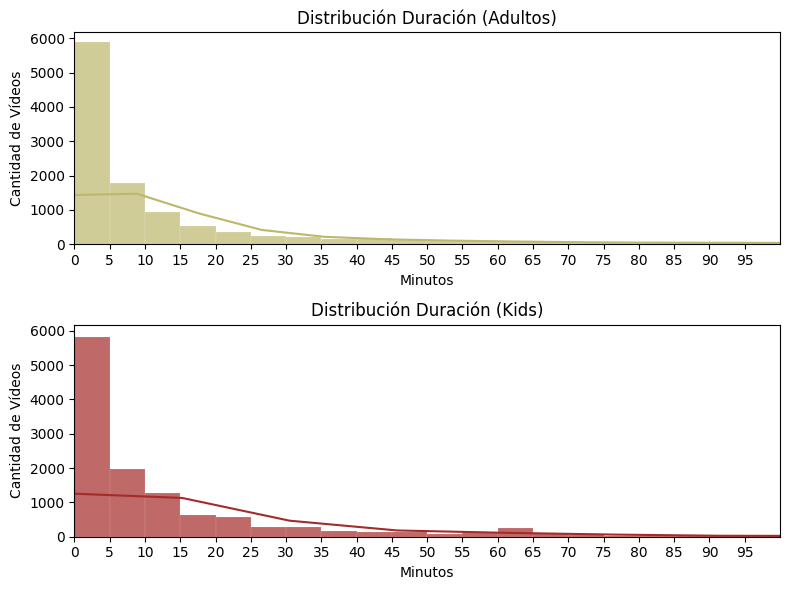

In [5]:

# Configuración
fig, ax = plt.subplots(2, 1, figsize=(8, 6), sharey=True)

utils.graficar_histograma_duracion(df_Adult, 'Distribución Duración (Adultos)', ax[0], 'darkkhaki')
utils.graficar_histograma_duracion(df_Kids, 'Distribución Duración (Kids)', ax[1], 'brown')

plt.tight_layout()
plt.show()

Kids: La distribución extremadamente concentrada en duraciones muy cortas (generalmente entre 0 y 10 minutos). Se puede observar que apenas hay videos de más de 15 minutos, lo que indica que el contenido infantil está diseñado para captar la atención de forma rápida y breve.

Adultos: Aunque también tiene un pico en duraciones cortas, hay más variedad. Desde vídeos cortos informativos (de entre 0-15 minutos) hasta contenidos más extensos que el público adulto es capaz de retener.

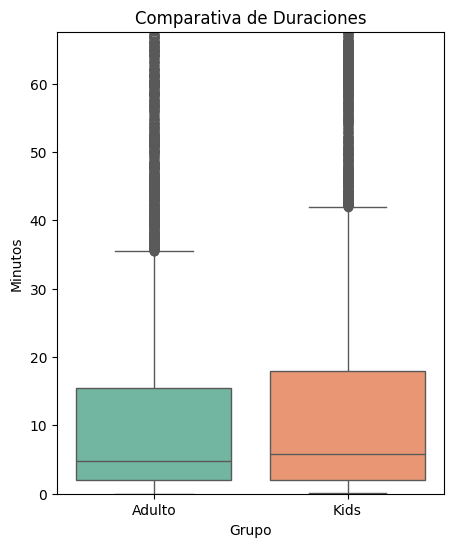

In [6]:
df_total = pd.concat([
    df_Adult.assign(Grupo='Adulto'),
    df_Kids.assign(Grupo='Kids')
])

plt.figure(figsize=(5, 6))
sns.boxplot(x='Grupo', y='Duracion', data=df_total, palette='Set2')     

# zoom para que se vea mejor
limite_superior = df_total['Duracion'].quantile(0.95) * 0.7 
plt.ylim(0, limite_superior) 

plt.title('Comparativa de Duraciones')
plt.ylabel('Minutos')
plt.show()

Como se puede observar la mediana es prácticamente igual para adultos que para niños. Esto sugiere que hay un tiempo ideal para mantener la atención antes de que el usuario pase al siguiente vídeo, independientemente de su edad. Se puede estimar que este valor está entre 5 y 8 minutos.

En ambos grupos vemos puntos por encima de los bigotes (outliers). En adultos estos valores extremos pueden llegar a duraciones mucho mayores, mientras que en niños, incluso los vídeos que se consideran más largos siguen teniendo una duración razonable.

## Top 10 géneros

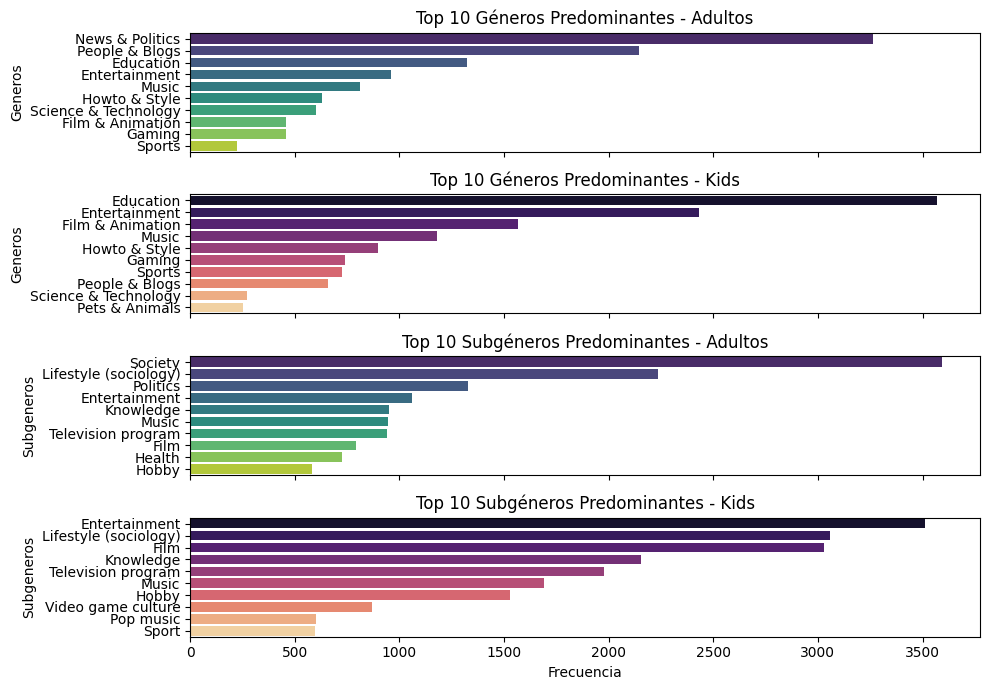

In [7]:
# Configuración
fig, ax = plt.subplots(4, 1, figsize=(10, 7), sharex=True)

# Llamamos a la función para cada grupo
utils.graficar_top_generos(df_Adult, 'Top 10 Géneros Predominantes - Adultos', ax[0], 'viridis', "Generos")
utils.graficar_top_generos(df_Kids, 'Top 10 Géneros Predominantes - Kids', ax[1], 'magma', "Generos")
utils.graficar_top_generos(df_Adult, 'Top 10 Subgéneros Predominantes - Adultos', ax[2], 'viridis', "Subgeneros")
utils.graficar_top_generos(df_Kids, 'Top 10 Subgéneros Predominantes - Kids', ax[3], 'magma', "Subgeneros")
plt.tight_layout()
plt.show()

El perfil del público adulto destaca por su fragmentación y heterogeneidad temática. Por un lado, tenemos contenidos informativos y de actualidad ('Blogs', 'Politics', 'Knowledge') y, por otro, un consumo más de ocio ('Music', 'Gaming'). 

En cuanto al público infantil, lso temas mas comunes son; 'Entertainment', 'Music', 'Film'. Se observa que los contenidos se inclinan más hacia temas lúdicos. Aunque tambien observamos cierto caracter educativo con generos como 'Knowledge'.

Observamos que los géneros más voluminosos (Education, Entertainment, Film & Animation) están presentes en ambos grupos. Esto genera una ambigüedad por lo que consideramos que la frecuencia de género no es suficiente para clasificar con seguridad.

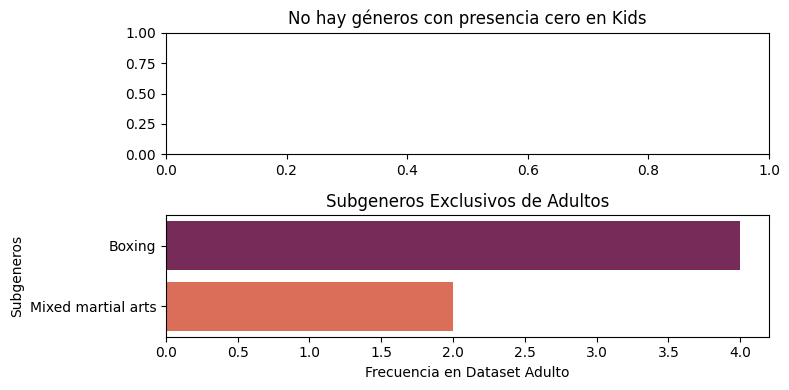

In [8]:
fig, ax = plt.subplots(2, 1, figsize=(8,4))
utils.graficar_generos_ausentes_kids(df_Adult, df_Kids, ax[0], "Generos")
utils.graficar_generos_ausentes_kids(df_Adult, df_Kids, ax[1], "Subgeneros")
plt.tight_layout()
plt.show()

La utilidad de los géneros en este modelo no reside en la frecuencia de los más usados, sino en la certeza de los ausentes, convirtiendo la escasez de datos en ciertas categorías en una herramienta de filtrado de alta precisión. Al cambiar la muestra de datos, ahora no hay géneros ausentes en Kids, pero antes hemos visto que tales géneros pueden ser, por ejemplo, "Physical Attractiveness", "Professional Wrestling" y "Boxing". 

La ausencia total de estos temas en el grupo Kids nos permite establecer una lista de generos "prohibidos". Si el clasificador detecta una de estas etiquetas en un vídeo, lo mejor es que este sea descartado como apto para niños, independientemente de si su vocabulario o duración sugieren lo contrario.

Por lo que hemos visto, los temas que no son aptos para niños tienen que ver principalente con la violencia.


## Densidad de habla (wpm)

In [9]:
#Agregamos una nueva columna a todos los df
df_Adult['Palabras_Por_Minuto'] = df_Adult.apply(utils.calcular_wpm, axis=1)
df_Adult['Palabras_Por_Minuto'] = round(df_Adult['Palabras_Por_Minuto'], 2)

df_Kids['Palabras_Por_Minuto'] = df_Kids.apply(utils.calcular_wpm, axis=1)
df_Kids['Palabras_Por_Minuto'] = round(df_Kids['Palabras_Por_Minuto'], 2)


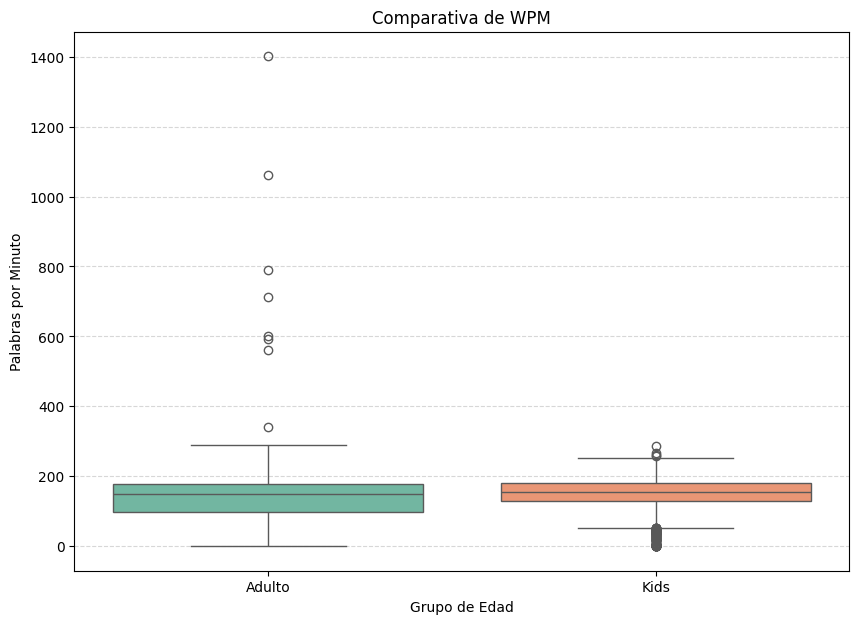

In [10]:
# Filtramos los vídeos sin palabras que no tienen subtitulos
df_wpm_total = pd.concat([
    df_Adult[df_Adult['Palabras_Por_Minuto'] > 0].assign(Grupo='Adulto'),
    df_Kids[df_Kids['Palabras_Por_Minuto'] > 0].assign(Grupo='Kids')
])

#Gráfica
plt.figure(figsize=(10, 7))

sns.boxplot(x='Grupo', y='Palabras_Por_Minuto', data=df_wpm_total, palette='Set2')

plt.title('Comparativa de WPM')
plt.xlabel('Grupo de Edad')
plt.ylabel('Palabras por Minuto')

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

Sorprendentemente, la mediana de palabras por minuto en el grupo Kids es ligeramente superior a la del grupo Adulto. Esto sugiere que, cuando un vídeo infantil es de carácter narrativo o educativo, mantiene un ritmo verbal constante y dinámico para mantener la atención del menor.

La caja del grupo infantil es notablemente más compacta. Esto indica que el contenido para niños sigue un estándar de producción muy rígido, el ritmo de habla es más uniforme.

El grupo Adulto presenta una caja mucho más amplia y bigotes más largos. Esto refleja la enorme heterogeneidad de su contenido; mientras que en Kids el ritmo es predecible, en adultos conviven géneros con una carga de guion mínima junto a otros de altísima densidad verbal.

Para nuestro clasificador, esto significa que el WPM por sí solo no define si un vídeo es para niños o adultos, sino su variabilidad.

Es importante señalar que la muestra de vídeos infantiles con subtítulos disponibles es considerablemente menor que la de adultos. Esto suguiere que los resultados de WPM en el grupo Kids podrían no ser plenamente representativos.

# Análisis textual

## Título

In [ ]:
df_tf_titulo_kids = utils.tfidf_ngrams_titles(df_Kids, "Titulo")
df_tf_titulo_adults = utils.tfidf_ngrams_titles(df_Adult, "Titulo")


In [29]:
common_terms = (
    df_tf_titulo_kids
    .merge(df_tf_titulo_adults, on="Titulo", suffixes=("_kids", "_adults"))
)

common_terms["Diff"] = common_terms["Score_kids"] - common_terms["Score_adults"]

common_terms.sort_values("Diff", ascending=False).head(20)

,Titulo,Score_kids,Score_adults,Diff
0,kids,264.868213,10.916251,253.951962
1,shorts,116.163461,25.972550,90.190911
3,songs,82.621059,5.467559,77.153500
2,song,84.565376,20.860114,63.705262
10,minecraft,63.700238,2.979256,60.720982
12,cartoon,62.565176,2.196389,60.368787
4,learn,76.812382,16.942034,59.870348
8,en,65.614612,6.845299,58.769313
11,videos,63.019098,5.785737,57.233361
14,draw,61.496445,5.329219,56.167226


In [30]:
kids_only = df_tf_titulo_kids[
    ~df_tf_titulo_kids["Titulo"].isin(df_tf_titulo_adults["Titulo"])
]
adults_only = df_tf_titulo_adults[
    ~df_tf_titulo_adults["Titulo"].isin(df_tf_titulo_kids["Titulo"])
]

print(adults_only.head(20))
kids_only.head(20)

            Titulo      Score
7617          iran  59.853341
3484        county  38.829999
15036    type beat  33.705414
2556           ceo  30.496494
8963    march 2026  27.254840
1207          asmr  19.611779
8032        killed  15.516776
5761      forecast  13.751265
12808       senate  13.560389
929           amid  13.340332
7638      iran war  12.252425
1158      arrested  11.161718
9295   middle east  10.938141
12036    residents  10.445063
7677        israel  10.301994
8277     lawmakers  10.090086
13515       speaks   9.285504
3175     committee   9.231662
15625      warning   9.130584
10002         noem   8.958216


,Titulo,Score
13893,rhymes,56.822446
11738,nursery rhymes,50.179098
8983,kids songs,44.706723
1941,blippi,41.957987
17433,videos kids,39.250059
2820,cartoons kids,38.515429
5275,educational,37.817522
11612,niños,33.430115
8722,khan academy,32.945497
12142,para niños,30.573842


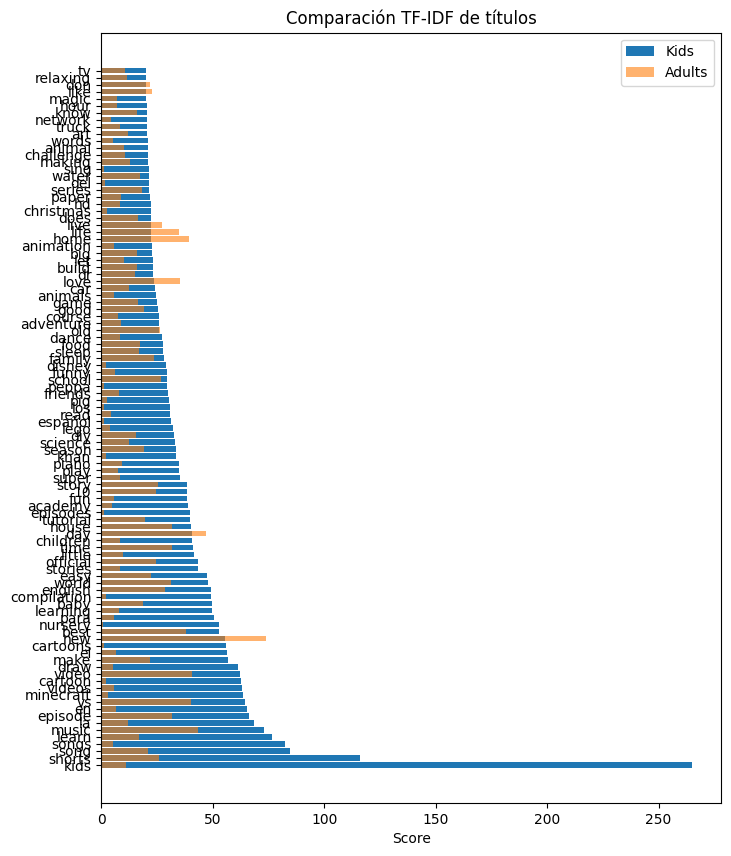

In [34]:
top_terms = common_terms.nlargest(100, "Score_kids")

plt.figure(figsize=(8,10))

plt.barh(top_terms["Titulo"], top_terms["Score_kids"], label="Kids")
plt.barh(top_terms["Titulo"], top_terms["Score_adults"], alpha=0.6, label="Adults")

plt.legend()
plt.title("Comparación TF-IDF de títulos")
plt.xlabel("Score")
plt.show()

In [49]:
topic_model_titulo, df_bertopic_titulo, temas_bertopic_titulo = utils.analizar_bertopic(df, "Titulo")


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
df_bertopic_titulo_kids = df_bertopic_titulo[df_bertopic_titulo["Rango_edad"].isin(rangos_kids)].copy()
df_bertopic_titulo_adults = df_bertopic_titulo[df["Rango_edad"] == "Adult"].copy()

print(f'Size of Kids: {len(df_bertopic_titulo_kids)}')
print(f'Size of Adults: {len(df_bertopic_titulo_adults)}')


Size of Kids: 12632
Size of Adults: 11511


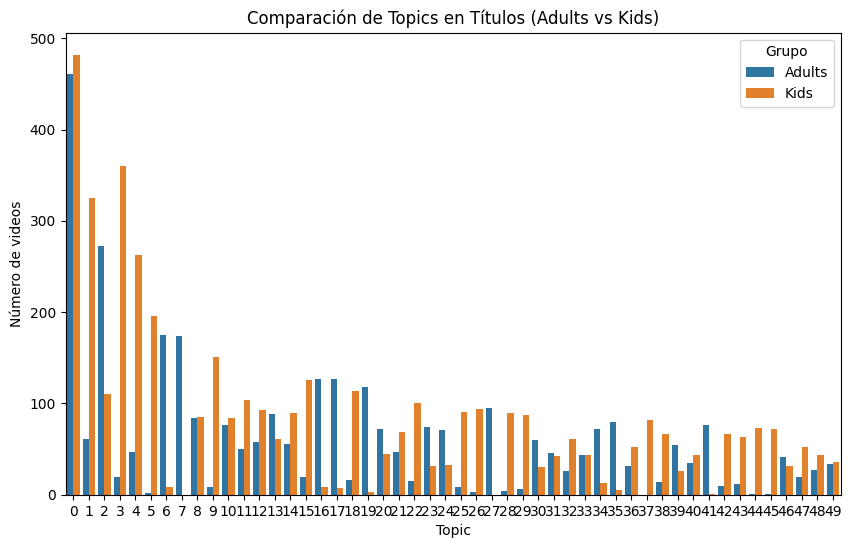

In [56]:
# contar topics
top_adults = df_bertopic_titulo_adults["Topic"].value_counts()
top_kids = df_bertopic_titulo_kids["Topic"].value_counts()

# eliminar outliers
top_adults = top_adults[top_adults.index != -1]
top_kids = top_kids[top_kids.index != -1]

# convertir a dataframe
df_adults = top_adults.reset_index()
df_adults.columns = ["Topic", "Count"]
df_adults["Grupo"] = "Adults"

df_kids = top_kids.reset_index()
df_kids.columns = ["Topic", "Count"]
df_kids["Grupo"] = "Kids"

# unir
df_plot = pd.concat([df_adults, df_kids])

# quedarnos con los topics más comunes
top_topics = (
    df_plot.groupby("Topic")["Count"]
    .sum()
    .sort_values(ascending=False)
    .head(50)
    .index
)

df_plot = df_plot[df_plot["Topic"].isin(top_topics)]

# gráfico
plt.figure(figsize=(10,6))
sns.barplot(data=df_plot, x="Topic", y="Count", hue="Grupo")

plt.title("Comparación de Topics en Títulos (Adults vs Kids)")
plt.ylabel("Número de videos")
plt.xlabel("Topic")
plt.show()

In [ ]:
plt.figure(figsize=(8,10))

plt.barh(top_terms["Titulo"], top_terms["Score_kids"], label="Kids")
plt.barh(top_terms["Titulo"], top_terms["Score_adults"], alpha=0.6, label="Adults")

plt.legend()
plt.title("Comparación TF-IDF de títulos")
plt.xlabel("Score")
plt.show()